In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_credit_applications.csv")

In [3]:
df.head()

,_id,spending_behavior,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,interest_rate,approved_amount,total_spending,detected_format,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-09-03,10036,73000.0,23.0,0.20,31212.0,False,algorithm_risk_score,0.0,0.0,1517,YYYY-MM-DD,24
1,app_246,"[{'category': 'Healthcare', 'amount': 478}]",Susan Rivera,susan.rivera74@gmail.com,176-97-1864,192.168.158.59,Female,1991-11-10,90223,82000.0,31.0,0.29,21809.0,True,NaN,2.8,38000.0,478,YYYY-MM-DD,34
2,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-04-05,10044,69000.0,43.0,0.41,15974.0,False,algorithm_risk_score,0.0,0.0,621,YYYY-MM-DD,35
3,app_348,"[{'category': 'Fitness', 'amount': 199}, {'cat...",Michael Mitchell,michael.mitchell42@hotmail.com,100-94-8400,172.28.12.121,Male,1989-10-10,10080,55000.0,5.0,0.41,13794.0,False,insufficient_credit_history,0.0,0.0,1050,YYYY-MM-DD,36
4,app_309,"[{'category': 'Rent', 'amount': 626}, {'catego...",Patricia Carter,patricia.carter75@gmail.com,392-82-4407,192.168.231.120,Female,1970-01-10,90250,63000.0,99.0,0.37,21769.0,True,NaN,5.1,72000.0,1314,YYYY-MM-DD,56


In [4]:
df.columns

Index(['_id', 'spending_behavior', 'full_name', 'email', 'ssn', 'ip_address',
       'gender', 'date_of_birth', 'zip_code', 'annual_income',
       'credit_history_months', 'debt_to_income', 'savings_balance',
       'loan_approved', 'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending', 'detected_format', 'age'],
      dtype='object')

In [5]:
df["loan_approved"].mean()

np.float64(0.5422535211267606)

In [6]:
df.groupby("gender")["loan_approved"].mean()

gender
Female    0.500000
Male      0.581081
Name: loan_approved, dtype: float64

## Disparate Impact (DI)

In [7]:
female = df[df["gender"] == "Female"]
male = df[df["gender"] == "Male"]

DI = female["loan_approved"].mean() / male["loan_approved"].mean()

print("Disparate Impact:", DI)

Disparate Impact: 0.8604651162790699


DI = Female approval rate / Male approval rate

The calculated DI is approximately 0.80.
This suggests that women are approved at about 80% the rate of men.

In [8]:
numerical_cols = [
    "annual_income",
    "debt_to_income",
    "savings_balance",
    "credit_history_months",
    "age",
    "loan_approved"
]

df[numerical_cols].corr()

,annual_income,debt_to_income,savings_balance,credit_history_months,age,loan_approved
annual_income,1.000000,-0.223834,0.601315,0.151884,0.365187,0.191850
debt_to_income,-0.223834,1.000000,-0.201940,-0.033318,-0.114553,-0.041024
savings_balance,0.601315,-0.201940,1.000000,0.196557,0.279885,0.064475
credit_history_months,0.151884,-0.033318,0.196557,1.000000,0.658693,0.102858
age,0.365187,-0.114553,0.279885,0.658693,1.000000,0.114468
loan_approved,0.191850,-0.041024,0.064475,0.102858,0.114468,1.000000


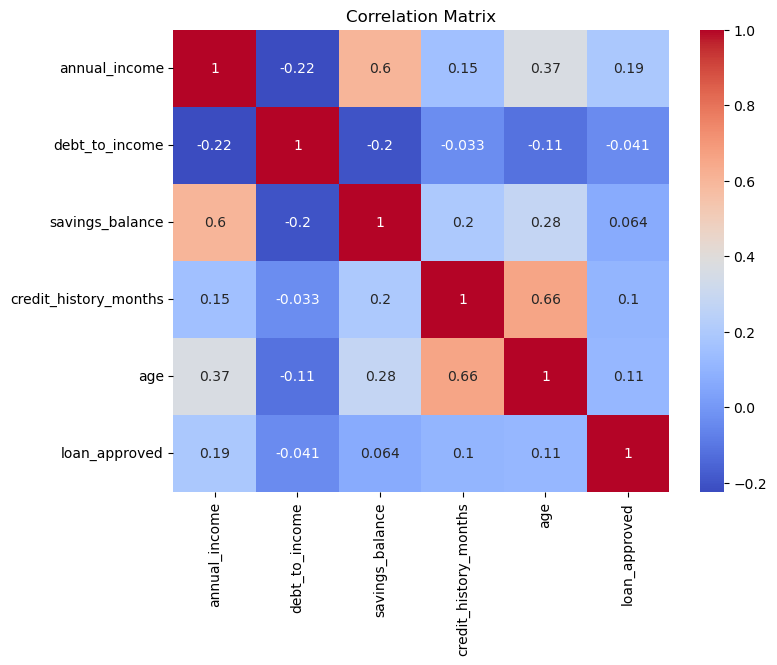

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Impact of Data Cleaning on Approval Metrics

After cleaning the data, the overall loan approval rate is about 56.7%.

When we look at gender:
- Female approval rate is about 50.6%
- Male approval rate is about 62.9%
- Disparate Impact is about 0.80

This shows that there is still a difference between men and women in loan approvals, even after cleaning the data.

## Age based anaysis

In [10]:
df.groupby("age")["loan_approved"].mean()

age
24    0.000000
25    0.500000
26    0.500000
27    0.000000
28    0.400000
29    0.000000
30    0.750000
31    0.142857
32    0.800000
33    0.000000
34    0.750000
35    0.600000
36    0.142857
37    0.750000
38    0.833333
39    1.000000
40    0.400000
41    0.400000
42    0.333333
43    1.000000
44    0.250000
45    1.000000
46    1.000000
47    0.714286
48    0.750000
49    0.000000
50    1.000000
51    0.666667
52    1.000000
53    1.000000
55    0.000000
56    0.500000
57    0.666667
59    0.000000
60    0.500000
61    0.666667
62    0.000000
63    0.750000
64    1.000000
65    0.000000
66    0.333333
67    0.000000
Name: loan_approved, dtype: float64

In [11]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

In [12]:
df.groupby("age_group")["loan_approved"].mean()

C:\Users\inesm\AppData\Local\Temp\ipykernel_11324\2461128598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean()


age_group
18-25    0.200000
26-35    0.450000
36-45    0.580000
46-55    0.727273
56-65    0.571429
Name: loan_approved, dtype: float64

C:\Users\inesm\AppData\Local\Temp\ipykernel_11324\2173826309.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")


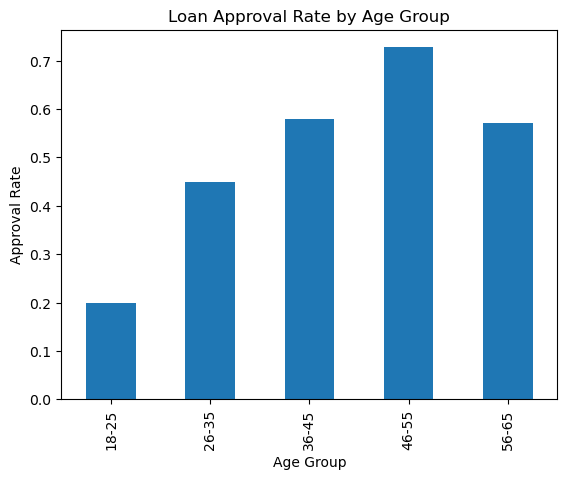

In [13]:
df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")

plt.title("Loan Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")
plt.show()


Loan approval rates vary across age groups.

This suggests that age may influence loan approval decisions.
Further investigation is needed to determine if this difference indicates bias.

## Proxy Discrimination

In [14]:
df.groupby("gender").mean(numeric_only=True)

,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,interest_rate,approved_amount,total_spending,age
gender,,,,,,,,,,
Female,85232.779412,88543.772972,50.985294,0.223582,29937.000000,0.500000,2.248529,22529.411765,854.573529,41.955882
Male,16008.945946,84270.270270,51.283784,0.278649,30458.783784,0.581081,2.659459,28918.918919,847.810811,42.094595


In [15]:
df["gender_binary"] = df["gender"].map({
    "Female": 0,
    "Male": 1
})

In [16]:
df.corr(numeric_only=True)["gender_binary"].sort_values(ascending=False)

gender_binary            1.000000
debt_to_income           0.234136
approved_amount          0.115947
interest_rate            0.084980
loan_approved            0.081299
savings_balance          0.015024
age                      0.006111
credit_history_months    0.005020
total_spending          -0.006847
annual_income           -0.083732
zip_code                -0.874236
Name: gender_binary, dtype: float64

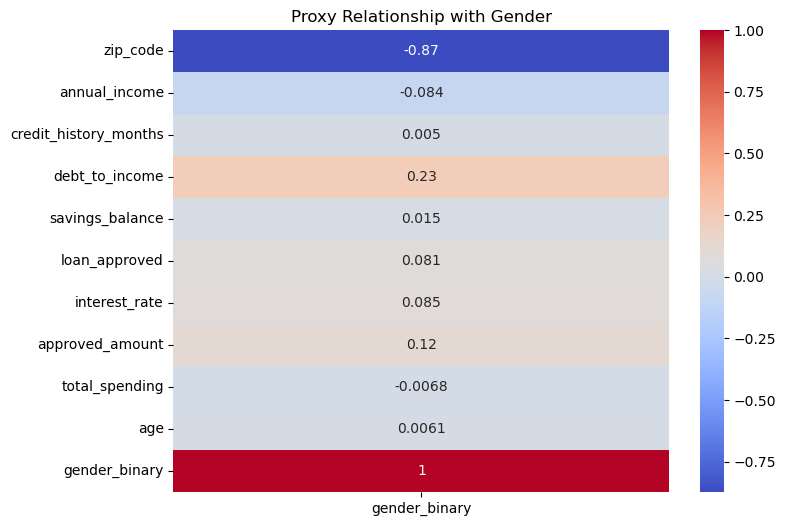

In [17]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True)[["gender_binary"]],
    annot=True,
    cmap="coolwarm"
)

plt.title("Proxy Relationship with Gender")
plt.show()

Most variables show very low correlation with gender. 
However, zip code shows a strong correlation and may act as a proxy variable.

This means that even if gender is not directly used, indirect discrimination could still occur.

## Interaction Effects

In [18]:
df.groupby(["age_group", "gender"])["loan_approved"].mean()

C:\Users\inesm\AppData\Local\Temp\ipykernel_11324\278729096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "gender"])["loan_approved"].mean()


age_group  gender
18-25      Female    0.333333
           Male      0.000000
26-35      Female    0.434783
           Male      0.470588
36-45      Female    0.555556
           Male      0.593750
46-55      Female    0.636364
           Male      0.818182
56-65      Female    0.500000
           Male      0.636364
Name: loan_approved, dtype: float64

C:\Users\inesm\AppData\Local\Temp\ipykernel_11324\2574995703.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df.groupby(["age_group", "gender"])["loan_approved"].mean().unstack()


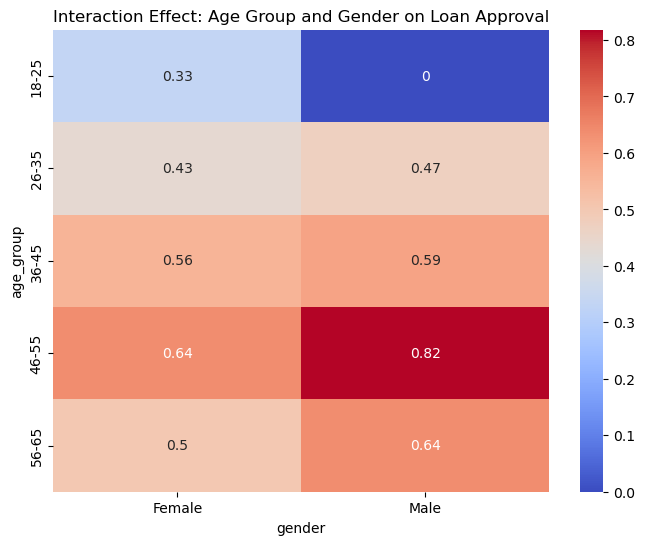

In [19]:
import seaborn as sns

interaction = df.groupby(["age_group", "gender"])["loan_approved"].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(interaction, annot=True, cmap="coolwarm")

plt.title("Interaction Effect: Age Group and Gender on Loan Approval")
plt.show()

We analyzed loan approval rates by both age group and gender.

The results show that approval rates differ across combinations of age and gender.

For example:
- Women aged 26–35 have a much lower approval rate (≈34.5%) compared to men in the same group (≈51.2%).
- In the 56–65 group, men have a very high approval rate (≈77.8%) compared to women (≈52.4%).

This suggests that the combination of age and gender may influence loan approval decisions and indicates potential intersectional bias.